# Análisis exploratorio de datos de un negocio de delivery de comida

- Objetivo: convertir datos crudos de pedidos en recomendaciones de negocio accionables, sin construir ningún modelo predictivo — el valor está en el criterio analítico, no en la complejidad técnica.
- El dataset es público: caso de estudio ampliamente usado en cursos de fundamentos de ciencia de datos, con pedidos de una app de delivery tipo agregador de restaurantes.
- Artículo completo, con el razonamiento detrás de cada decisión: [fuzzyfrog.ai/es/ai-lab/proyectos/negocios/analisis-exploratorio-datos-delivery-comida-python](https://fuzzyfrog.ai/es/ai-lab/proyectos/negocios/analisis-exploratorio-datos-delivery-comida-python/)


## Diagrama del análisis

- **Entrada:** pedidos individuales con costo, tiempo de preparación, tiempo de entrega, calificación y restaurante.
- **Chequeo de calidad:** tipos de dato, valores faltantes, valores categóricos con codificación mixta (la calificación mezcla números y el texto "Not given").
- **Análisis univariado:** distribución de cada variable por separado.
- **Análisis bivariado:** relaciones entre variables — calificación vs tiempo, día de la semana vs entrega, etc.
- **Traducción de reglas de negocio:** condiciones de promoción y comisión escalonada expresadas como código, no solo como texto.
- **Salida:** recomendaciones de negocio respaldadas por un número específico, no una opinión genérica.


## Carga de datos

- El dataset tiene 1,898 pedidos con 9 columnas: identificadores, restaurante, tipo de cocina, costo, día de la semana, calificación, tiempo de preparación y tiempo de entrega.
- Es un dataset público, usado como caso de estudio en cursos de análisis de datos — no corresponde a ningún cliente o proyecto confidencial.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# En Colab:
# from google.colab import drive
# drive.mount('/content/drive')
# df = pd.read_csv('/content/drive/MyDrive/tu_carpeta/foodhub_order.csv')

df = pd.read_csv("dataset/foodhub_order.csv")
df.head()


,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


In [2]:
print(f"Filas: {df.shape[0]}, columnas: {df.shape[1]}")
df.info()


Filas: 1898, columnas: 9
<class 'pandas.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   str    
 3   cuisine_type           1898 non-null   str    
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   str    
 6   rating                 1898 non-null   str    
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), str(4)
memory usage: 133.6 KB


## Explicación de datos

- Cada fila es un pedido: quién lo hizo, en qué restaurante, qué tipo de cocina, cuánto costó, qué día fue, cómo lo calificó el cliente, y cuánto tardó en prepararse y entregarse.
- La columna `rating` mezcla texto y número: contiene los valores `'Not given'`, `'3'`, `'4'`, `'5'` como strings — no se puede promediar directamente sin antes separar los pedidos sin calificación.


In [3]:
# Verificar valores faltantes
print("Valores faltantes por columna:")
print(df.isnull().sum())


Valores faltantes por columna:
order_id                 0
customer_id              0
restaurant_name          0
cuisine_type             0
cost_of_the_order        0
day_of_the_week          0
rating                   0
food_preparation_time    0
delivery_time            0
dtype: int64


In [4]:
df.describe()


,order_id,customer_id,cost_of_the_order,food_preparation_time,delivery_time
count,1.898000e+03,1898.000000,1898.000000,1898.000000,1898.000000
mean,1.477496e+06,171168.478398,16.498851,27.371970,24.161749
std,5.480497e+02,113698.139743,7.483812,4.632481,4.972637
min,1.476547e+06,1311.000000,4.470000,20.000000,15.000000
25%,1.477021e+06,77787.750000,12.080000,23.000000,20.000000
50%,1.477496e+06,128600.000000,14.140000,27.000000,25.000000
75%,1.477970e+06,270525.000000,22.297500,31.000000,28.000000
max,1.478444e+06,405334.000000,35.410000,35.000000,33.000000


**Observación real:** el tiempo de preparación va de 20 a 35 minutos, con un promedio de 27.37. El tiempo de entrega promedio es 24.16 minutos. Ninguna columna tiene valores nulos, pero eso no significa que todos los datos estén "limpios" — la calificación tiene 736 pedidos marcados como `'Not given'`, que es un valor faltante disfrazado de string, no un `NaN`.


## Análisis de datos — univariado y bivariado

Antes de responder cualquier pregunta de negocio, se exploran las variables por separado y después en pares — nunca se salta directo a la conclusión sin ver la distribución primero.


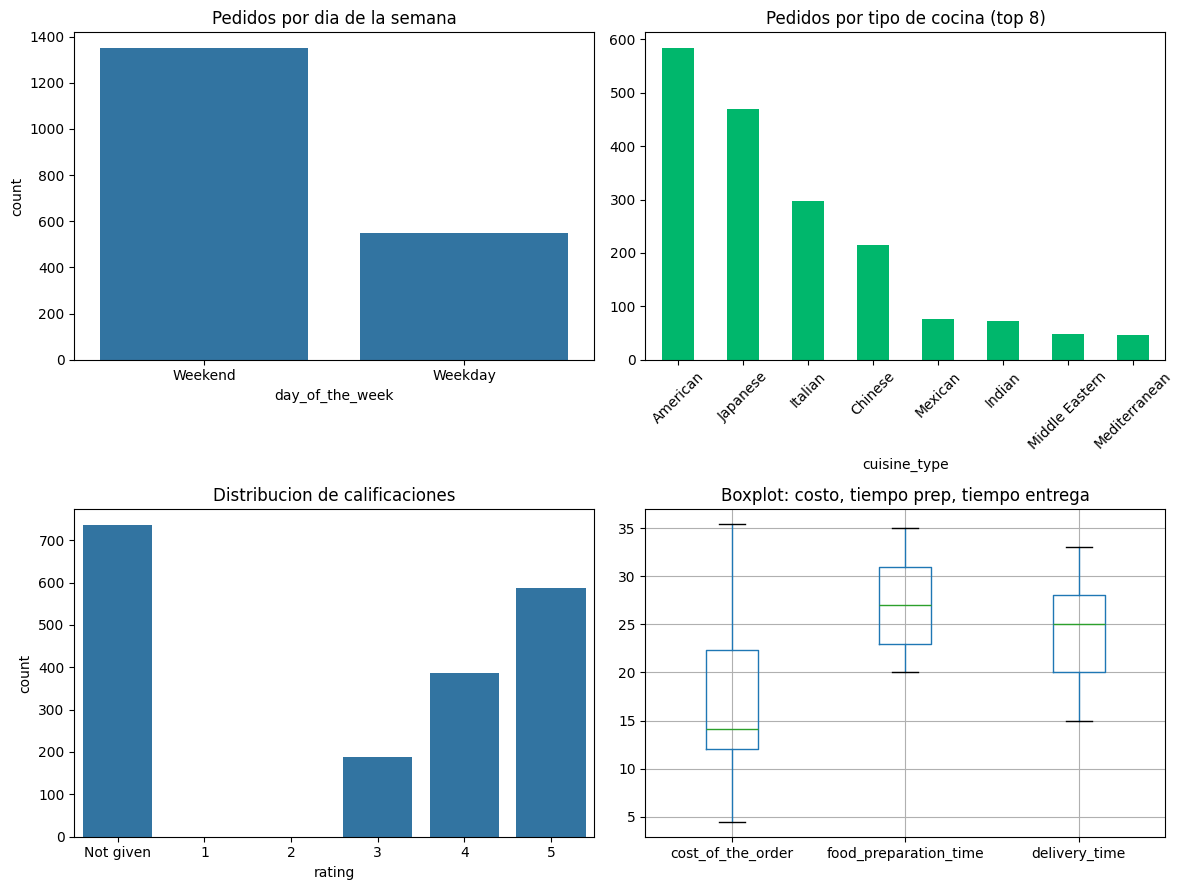

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
sns.countplot(x=df["day_of_the_week"], ax=axes[0,0])
axes[0,0].set_title("Pedidos por dia de la semana")

df.cuisine_type.value_counts().head(8).plot.bar(ax=axes[0,1], color="#00b76c")
axes[0,1].set_title("Pedidos por tipo de cocina (top 8)")
axes[0,1].tick_params(axis='x', rotation=45)

sns.countplot(x=df["rating"], order=['Not given','1','2','3','4','5'], ax=axes[1,0])
axes[1,0].set_title("Distribucion de calificaciones")

df.boxplot(column=['cost_of_the_order','food_preparation_time','delivery_time'], ax=axes[1,1])
axes[1,1].set_title("Boxplot: costo, tiempo prep, tiempo entrega")

plt.tight_layout()
plt.show()


**Hallazgo real que no se esperaba de entrada:** en la distribución de calificaciones no existe ninguna calificación de 1 o 2 estrellas — solo aparecen `Not given`, 3, 4 y 5. O el sistema no permite calificar por debajo de 3, o los clientes insatisfechos prefieren no calificar en vez de dejar una calificación baja. Cualquiera de las dos interpretaciones cambia cómo se debería leer el 39% de pedidos sin calificar: no es ruido, es una señal de insatisfacción escondida.


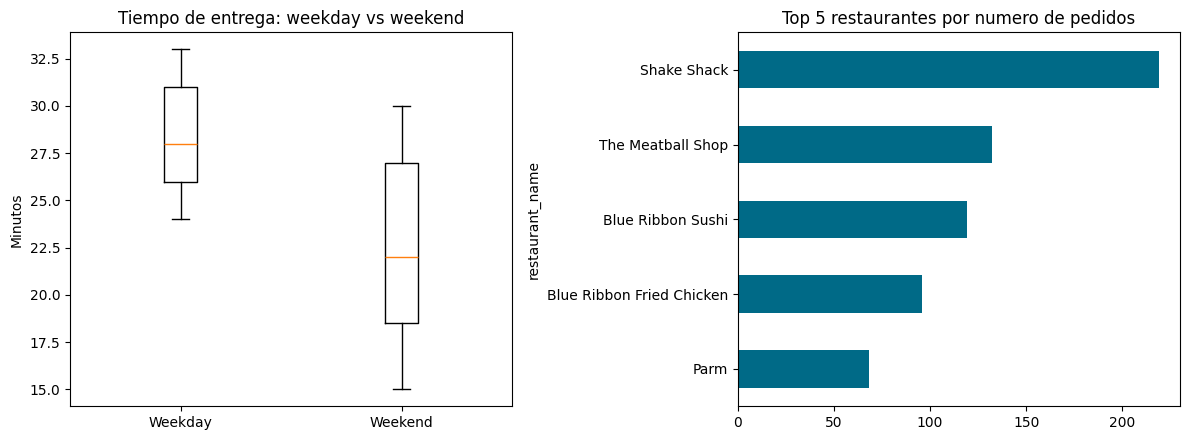

In [6]:
fig2, axes2 = plt.subplots(1, 2, figsize=(12, 4.5))
weekday_dt = df[df.day_of_the_week == 'Weekday']['delivery_time']
weekend_dt = df[df.day_of_the_week == 'Weekend']['delivery_time']
axes2[0].boxplot([weekday_dt, weekend_dt], tick_labels=['Weekday', 'Weekend'])
axes2[0].set_title("Tiempo de entrega: weekday vs weekend")
axes2[0].set_ylabel("Minutos")

df.restaurant_name.value_counts().head(5).plot.barh(ax=axes2[1], color="#006a87")
axes2[1].set_title("Top 5 restaurantes por numero de pedidos")
axes2[1].invert_yaxis()

plt.tight_layout()
plt.show()


In [7]:
mean_weekday = df[df.day_of_the_week=='Weekday']['delivery_time'].mean()
mean_weekend = df[df.day_of_the_week=='Weekend']['delivery_time'].mean()
print(f"Tiempo de entrega promedio - Weekday: {mean_weekday:.2f} min | Weekend: {mean_weekend:.2f} min")


Tiempo de entrega promedio - Weekday: 28.34 min | Weekend: 22.47 min


## Modelado — traducción de reglas de negocio a código

Este proyecto no entrena ningún modelo predictivo. La parte que sí requiere criterio de ingeniería es traducir reglas de negocio ambiguas en texto a condiciones exactas en código, sin dejar casos sin cubrir.


In [8]:
# Regla: comision de 25% en pedidos > $20, 15% en pedidos entre $5 y $20 (inclusive), 0% en pedidos <= $5
pedidos_25 = df[df['cost_of_the_order'] > 20]
pedidos_15 = df[(df['cost_of_the_order'] > 5) & (df['cost_of_the_order'] <= 20)]

comision_25 = (pedidos_25['cost_of_the_order'] * 0.25).sum()
comision_15 = (pedidos_15['cost_of_the_order'] * 0.15).sum()
revenue_total = comision_25 + comision_15

print(f"Revenue por comisiones: ${revenue_total:,.2f}")


Revenue por comisiones: $6,166.30


**Decisión clave:** la regla de negocio, tal como se redactó, no dice explícitamente qué pasa con los pedidos de $20 exactos o $5 exactos. Se interpretó `> 20` para el tramo de 25% y `> 5 y <= 20` para el de 15% — dejando implícito que un pedido de exactamente $20 cae en el tramo de 15%, no en el de 25%. Ese límite, si no se decide explícitamente, puede cambiar el revenue reportado sin que nadie note por qué.


In [9]:
# Restaurantes elegibles para promocion: mas de 50 calificaciones Y promedio > 4
df_calificados = df[df['rating'] != 'Not given'].copy()
df_calificados['rating'] = df_calificados['rating'].astype('float64')

conteo_calificaciones = df_calificados['restaurant_name'].value_counts()
elegibles_por_volumen = conteo_calificaciones[conteo_calificaciones > 50].index

restaurantes_promocion = []
for restaurante in elegibles_por_volumen:
    promedio = df_calificados[df_calificados['restaurant_name'] == restaurante]['rating'].mean()
    if promedio > 4:
        restaurantes_promocion.append((restaurante, conteo_calificaciones[restaurante], round(promedio, 2)))

print("Restaurantes que califican para la promocion (>50 calificaciones y promedio >4):")
for r in restaurantes_promocion:
    print(f"  {r[0]}: {r[1]} calificaciones, promedio {r[2]}")


Restaurantes que califican para la promocion (>50 calificaciones y promedio >4):
  Shake Shack: 133 calificaciones, promedio 4.28
  The Meatball Shop: 84 calificaciones, promedio 4.51
  Blue Ribbon Sushi: 73 calificaciones, promedio 4.22
  Blue Ribbon Fried Chicken: 64 calificaciones, promedio 4.33


**Decisión clave:** convertir `rating` a número solo después de filtrar `'Not given'`, nunca antes. Convertir la columna completa a float sin filtrar primero habría lanzado un error o, peor, generado `NaN` silenciosos que se cuelan en el promedio sin que se note el problema hasta mucho más adelante.


## Evaluación — validar las recomendaciones contra los datos

Antes de convertir un hallazgo en una recomendación de negocio, se revisa si el número respalda la afirmación con el margen suficiente, no solo si apunta en la dirección esperada.


In [10]:
df['total_time'] = df['food_preparation_time'] + df['delivery_time']
pct_mas_60min = (df['total_time'] > 60).mean() * 100
print(f"Porcentaje de pedidos que tardan mas de 60 min en total: {pct_mas_60min:.2f}%")


Porcentaje de pedidos que tardan mas de 60 min en total: 10.54%


In [11]:
cuisine_weekend = df[df.day_of_the_week == 'Weekend']['cuisine_type'].value_counts()
print("Tipos de cocina mas pedidos en fin de semana:")
print(cuisine_weekend.head(5))


Tipos de cocina mas pedidos en fin de semana:
cuisine_type
American    415
Japanese    335
Italian     207
Chinese     163
Mexican      53
Name: count, dtype: int64


**Observación:** aunque la cocina americana es la más pedida en general y en fin de semana, la diferencia contra la japonesa (segundo lugar) no es abrumadora — recomendar "enfocarse solo en comida americana" sin mencionar esa cercanía sería una simplificación que no refleja los datos con precisión.


## Hallazgos principales

- El 39% de pedidos sin calificar no es ruido aleatorio: la ausencia total de calificaciones de 1 y 2 estrellas sugiere que el silencio del cliente reemplaza la calificación negativa, no la evita.
- Una regla de negocio en texto siempre tiene casos límite no explícitos (¿qué pasa exactamente en $20.00?) — decidirlos explícitamente en el código evita que el revenue reportado dependa de un supuesto no documentado.
- Convertir un tipo de dato mixto (texto + número en la misma columna) requiere filtrar antes de castear, nunca al revés, o el error se esconde como un `NaN` silencioso.
- El fin de semana concentra más del doble de pedidos que la semana entera de días hábiles, y también tiene menor tiempo de entrega — dos señales que apuntan a la misma causa probable: menos tráfico, más pedidos, entregas más rápidas.
